In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_manipulation import add_era_to_all, add_round_group, round_group_summary
from src.data_plotting import plot_country_metrics, plot_italy_season_trend, plot_era_boxplots

from src.step1_functions import add_derived_metrics, era_summary_table, era_delta_table, depth_summary_table, milestone_counts, test_match_metrics, test_depth

In [2]:
# import data
raw_data = pd.read_csv('./data/uefa_results.csv')
country_stats = pd.read_pickle('./data/processed/country_stats_complete.pkl')
country_season_highest = pd.read_pickle('./data/processed/country_season_highest.pkl')
country_season_competition_highest = pd.read_pickle('./data/processed/country_season_competition_highest.pkl')

# 

italy_cs = pd.read_pickle('./data/processed/italy_cs.pkl')
italy_csh = pd.read_pickle('./data/processed/italy_csh.pkl')

In [3]:
italy_cs_reduced_columns = ['country', 
                            'season', 
                            'era',
                            'num_teams',
                            'total_matches', 
                            'wins', 
                            'draws', 
                            'losses',
                            'goals_for', 
                            'goals_against', 
                            'win_rate', ''
                            'ppg_3', 
                            'goal_diff', 
                            'gdpg',]

# Beyond the Golden Era: Tracking Italian Club Performance in Europe

In recent years, football pundits and commentators have frequently discussed a supposed crisis in Italian football, affecting both the national team and club competitions. Some extend this claim to the entire Italian football "ecosystem" including youth development, coaching structures, competitive performance, and even fan engagement across broadcast, streaming, and stadium attendance.

Alongside this narrative, a persistent myth has taken hold: the tendency to compare modern Italian football unfavourably with that of the 1990s, often nostalgically framed as a “golden era” for Italian clubs. (As with all golden ages, it tends to become shinier with time.)

In this notebook, we focus on a specific and measurable aspect of this broader debate: the performance of Italian clubs in major European competitions. Our goal is to assess whether the 1990s truly deserve their "golden age" status. To do so, we define a time window corresponding to this period and systematically compare its outcomes with those of the preceding and subsequent eras.

## The Data

The data used in this analysis were scraped from the [kassiesa.net UEFA results archive](https://kassiesa.net/uefa/index.html) which compiles results from major UEFA club competitions starting from the 1956/57 season. For the purposes of this study, we restrict the dataset to seasons from 1969/70 through to the present.

Overall, the dataset includes approximately 26,000 matches spanning 57 seasons, large enough to be statistically meaningful, and just small enough to still fit (somewhat reluctantly) in memory.

## Definition of Golden Era

There is no formal academic definition of the Italian “Golden Age,” but most pundits and fans share the view that the 1990s were a period in which Italian clubs displayed exceptional brilliance and dominance.

For the purposes of this analysis, we define the Golden Era as spanning from the 1987/88 season to the 1999/00 season. This choice is inherently arbitrary. We begin in 1987/88 because it marks the season in which AC Milan won its first Italian league title under the ownership of Silvio Berlusconi. His presidency is widely regarded, particularly in Italy, as a major catalyst for the broader football ecosystem, prompting other club owners to increase investment in order to remain competitive.

Another factor supporting this starting point is that Italy was preparing to host the 1990 FIFA World Cup, which led to significant government spending on the renovation and construction of stadiums.

## Formal Framework

Given the available data and our definition of the Golden Era, we now establish a formal framework to assess whether this period was indeed exceptional. To do so, we decompose the main research question into two independent, testable hypotheses:

- $H_{level}$ (level): Italy’s match-level performance (win rate, points, goal difference) was higher during the Golden Era than in the other two eras.
- $H_{depth}$ (depth): Italian clubs progressed further in knockout stages during the Golden Era than in the other two eras.

These two testable hypotheses will be evaluated under the following scenarios:

1. ***Within-Italy comparison across eras***<br>
  We compare Italian clubs’ performance during the Golden Era with that of the preceding and subsequent periods. If the selected metrics are statistically significantly higher during the Golden Era, we conclude that, at least from a performance standpoint, the "Golden Era" is not a myth.<br>
  *(This comparison is based exclusively on results achieved by Italian clubs.)*
2. ***Cross-country comparison within the Golden Era***<br>
We compare Italian clubs’ performance during the Golden Era with that of other European clubs competing in the major UEFA competitions: the UEFA Champions League (formerly the European Champion Clubs’ Cup), the UEFA Cup Winners' Cup, and the UEFA Europa League (formerly the UEFA Cup).

The second analysis is further divided into two levels: first, using an aggregate performance metric across all matches and competitions; and second, disaggregating by competition to assess whether differences emerge between tournaments.

Proposed metrics:

| Pillar | Metric | Source column | Why |
|:-------|:-------|:--------------|:----|
|Match performance  | Win rate | `win_rate` | Direct efficiency measure |
|Match performance  | points per game (*PPG*) | `ppg_3`/`num_teams` | Normalise per quota size |
|Match performance  | Goal Difference per Game (*GD per game*) | `gdpg` | Quality of wins, not just binary |
|Tournament depth  | Avg deepest round | `highest_round` | How far teams progressed |
|Tournament depth  | Finals/semis count | `highest_round` | Absolute peak moments |

## Statistical approach

Each metric produces one value per season. With ~17 seasons per era at most, samples are small and unlikely to be normal, so we use non-parametric tests throughout.

- Mann-Whitney $U$ — pairwise: Golden vs Pre, Golden vs Post. One-tailed (alternative="greater") since we are testing a directional hypothesis.
- Cohen's $d$ — effect size alongside every p-value. A statistically significant result with a tiny effect size is not analytically meaningful.
- Significance threshold — $\alpha$ = 0.05, with 0.1 as a weak signal worth noting.

It might be worth spending a few words on what a statistical test is and how we are using it in this analysis. Disclaimer: this is written for a general audience, not a scientific one. We aim to preserve the rigour of the analysis, but the explanation below focuses on intuition rather than technical detail.

In this analysis, we basically compute average values of some metrics. As an example, consider win rates, i.e. the percentage of matches won by all teams belonging to a specific country. For each season, we obtain one value; over an era, this gives us a collection of values. For instance, the average win rate of Italian clubs in the pre-Golden Era might be 0.3. Of course, there is variability: in one season it might be 0.2, in another 0.5, and so on. The standard deviation captures how much these values fluctuate around the mean.

So, for each era, we end up with a mean value and a measure of variability. The natural question is: how can we compare these values across eras? 

*What does it mean that two mean values differs from a statistical point of view?* 

- A familiar example: the "normal world"

A common starting point in statistics is to assume that data follow a Normal (Gaussian) distribution, the well-known bell-shaped curve. In that setting, each group is summarised by a mean and a standard deviation, and comparing two groups typically means comparing their means, taking into account their variability.

For example, suppose the Golden Era has an average win rate of 0.6 with a standard deviation of 0.07, while the pre-Golden Era has an average of 0.5 with a standard deviation of 0.1. The question becomes: is 0.6 really higher than 0.5, or could this difference be explained by variability?

To answer this, we perform a hypothesis test. We start with a null hypothesis: the two eras are not different. The alternative hypothesis states that they are different—and, in our case, that the Golden Era performs better.

Under the normality assumption, statistical tests evaluate how likely it is to observe a difference like the one we see (or more extreme) if the null hypothesis were true. This probability is the p-value.

If the p-value is larger than a predefined threshold $\alpha$, the observed difference is not statistically significant—meaning that, although the numbers differ, the difference could plausibly be due to random variation (or, as it is often said, “within the error”).

(We will skip the many philosophical debates around p-values—some of us have spent far too many evenings on those already.)

This "normal world" is a useful reference, but it relies on assumptions. In our case, the sample size (number of seasons per era) is relatively small, and we cannot safely assume that the data follow a normal distribution. But no need to worry: in the past, while most of us were spending time in pubs or clubs drinking, dancing, and generally enjoying life, some heroes were at home doing the hard maths to solve exactly this kind of problem. In our case, let’s raise a glass to Mann and Whitney, who developed a test called non-parametric (you don’t need to know why it’s called that; I am mostly mentioning it to because it’s Saturday night and I am writing this on a computer so you can have an idea about who is the people that is thrilled to know what the non-parametric tests are) that would work in our scenario .

In a non-parametric test, instead of comparing means directly, the Mann–Whitney $U$ test compares the relative ordering of values between two groups. In simple terms, it asks: Are values from one era generally higher than those from another? This approach does not rely on the normality assumption and is therefore better suited to small samples like ours.

The test still produces a *p-value*, which we interpret in the same way as before: if it is small enough, we reject the null hypothesis and conclude that the difference is unlikely to be due to chance.

Summing up, the Mann-Whitney $U$ test will give us the *p-value* that we will use to compare the means obtained in the different cases. Moreover, once we find that a difference is statistically significant, the Cohen's *d* value is a measure of the effect size: OK, there was a difference, but was it big or not that much? Another drink to salute Cohen!.

## Fu vera gloria? - Was it really a Golden Era?

The first question we will address if to check if the period between season 1987/88 and 1990/00 was really a golden age for Italian Clubs. Clearly, this statement can be addressed in different way, and in this notebook we will evaluate the performances of Italian Teams in the major European Competitions and compare results in the Golden Era with both the period preceding and after it. The evaluation in the European Competitions is a stronger indicator of a greater quality as the competitions involved teams competing in different national leagues and so the comparison is melted within matches not from the same national league (serie A).

### Match Performances

The first part of our tests involved match performances: where the results of the match played significantly better during the Golden Age? 

From the raw dataset containing all matches played in the European Cups, we extract the ones played by Italian Teams and compute, for each season, the number of game played, total number of italian teams involved that season, number of wins, draws, losses, total number of goals scored and against, the win rate and other measues like the points per game and points per game per team. A subset of the dataset looks like the following table (we are not reporting all columns but just some of the most relevant): 

In [4]:
italy_cs[italy_cs_reduced_columns].sample(5, random_state = 3).sort_values(by = 'season')

,country,season,era,num_teams,total_matches,wins,draws,losses,goals_for,goals_against,win_rate,ppg_3,goal_diff,gdpg
13,Ita,1982/83,Pre-Golden Era,5,29,12,5,12,40.0,33.0,0.413793,1.413793,7.0,0.241379
28,Ita,1997/98,Golden Era,7,55,33,9,13,97.0,49.0,0.600000,1.963636,48.0,0.872727
31,Ita,2000/01,Post-Golden Era,8,64,29,20,15,109.0,69.0,0.453125,1.671875,40.0,0.625000
45,Ita,2014/15,Post-Golden Era,6,79,38,24,17,122.0,74.0,0.481013,1.746835,48.0,0.607595
54,Ita,2023/24,Post-Golden Era,7,78,38,22,18,123.0,82.0,0.487179,1.743590,41.0,0.525641


A chart plotting the win rate (*number of wins divided by total matches*) across the season will visualize the trend of this parameter during the year.

  Saved -> ../charts/test_italy_season_trend.png


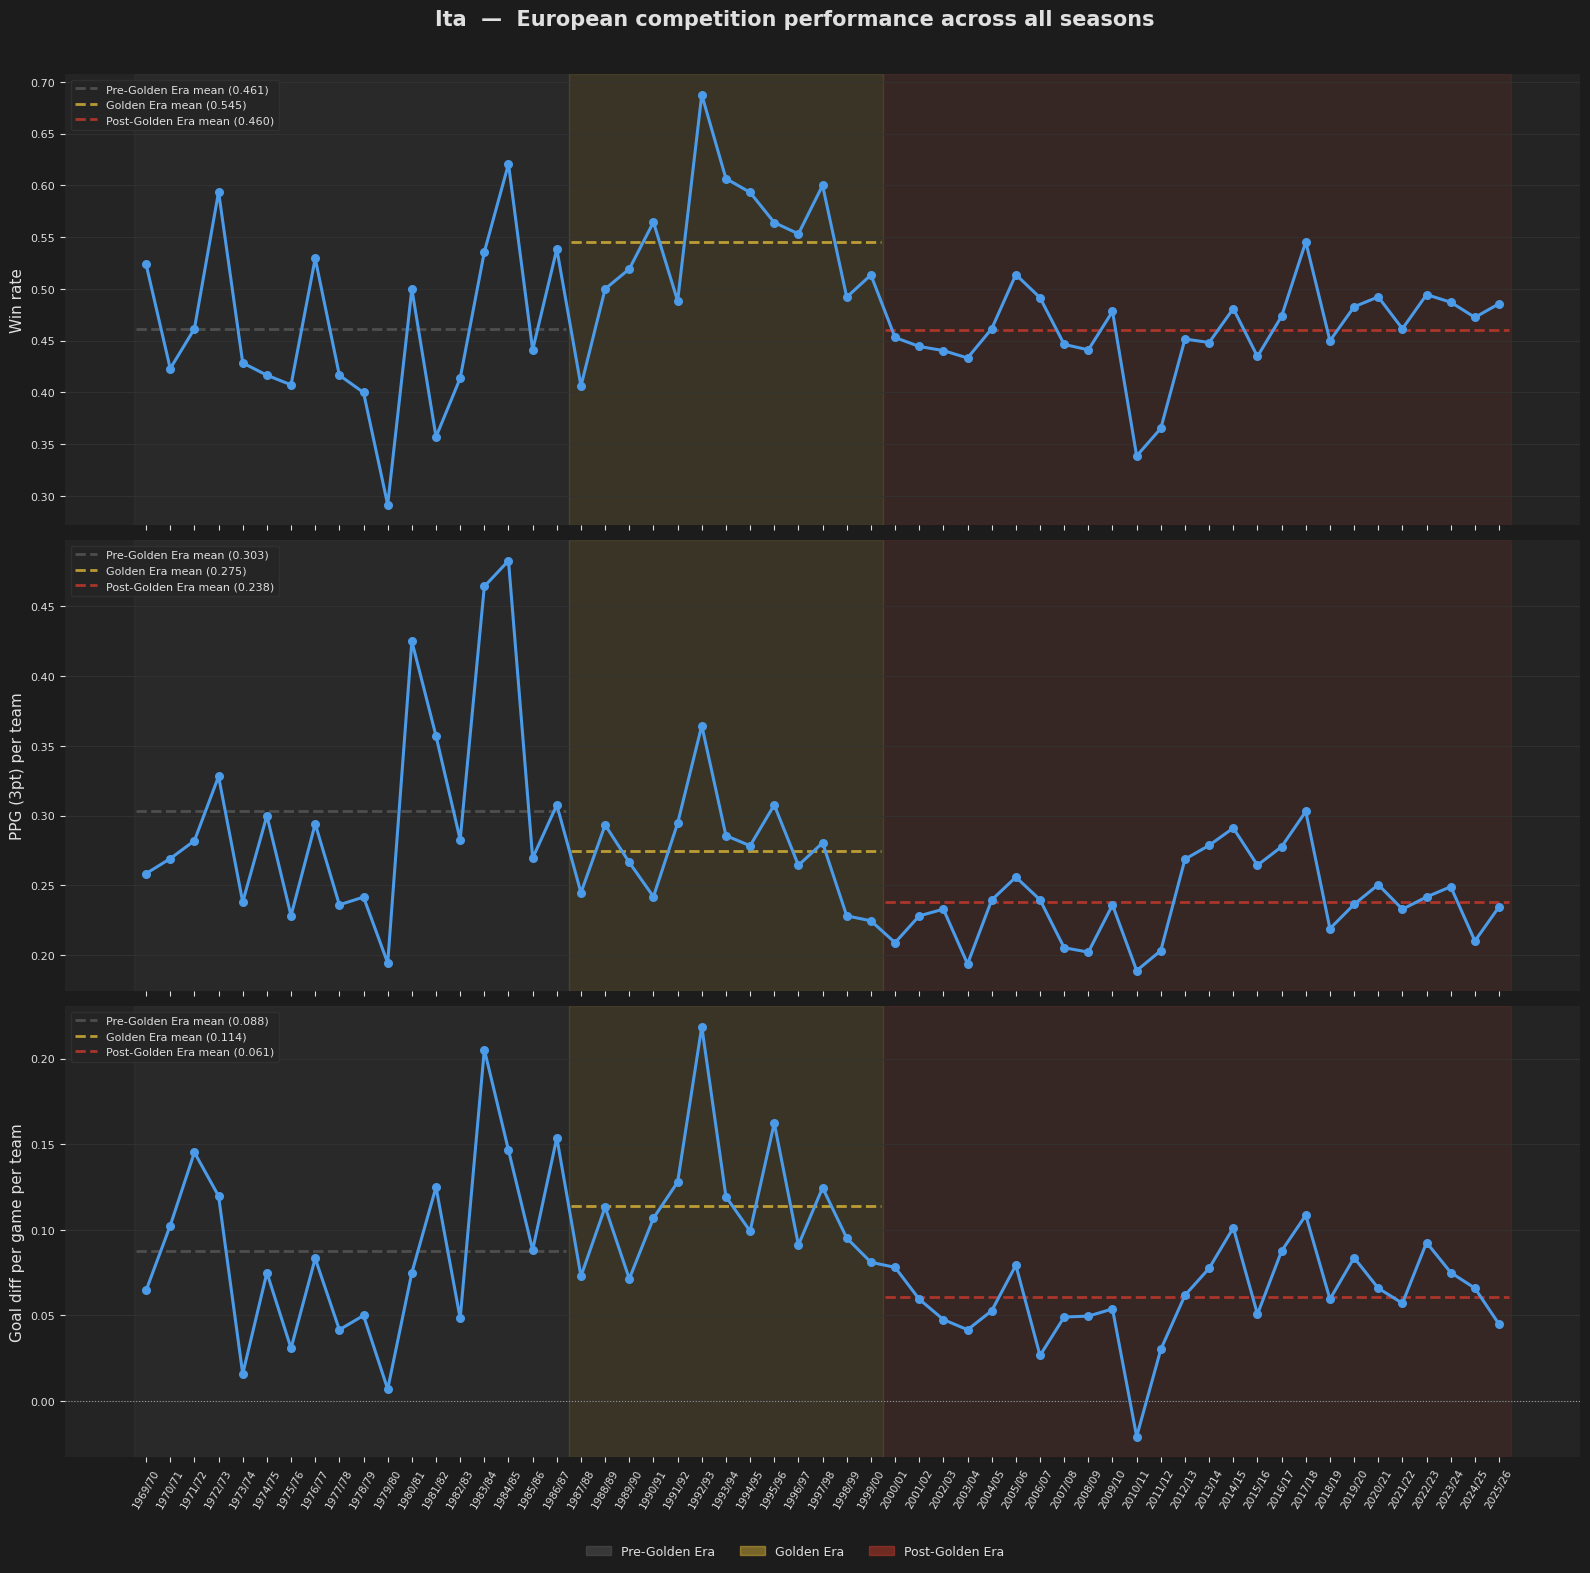

In [5]:
plot_italy_season_trend(italy_cs, charts_dir="../charts/", country_name="Ita",filename='test_italy_season_trend.png')

A box plot also show the distribution and outliers in the data.

  Saved -> ../charts/test_boxplot.png


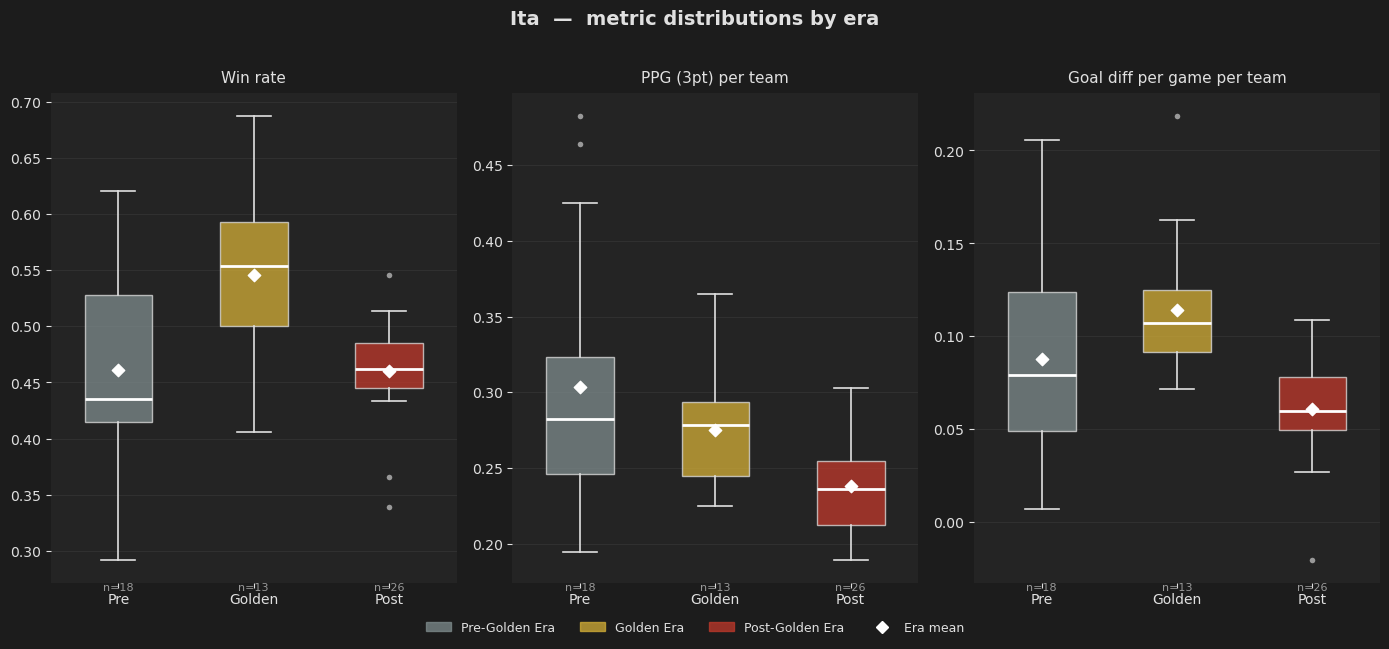

In [6]:
plot_era_boxplots(italy_cs, charts_dir="../charts/", country_name="Ita", filename='test_boxplot.png')

Looking at the plots, we can see, from the first figure, that the mean Win Rate and goal difference per game (the dashed lines) in the three eras look different, with the golden dashed line during seasons 1987/88 to 1999/00 higher with respect to the other areas. Is this difference statistically significant? Thats for the tests answer this question (see later section). 

Something interesting to note from the boxplot:
1. PPG per team, again, just show a consistency in the points gained as the number of teams increased during the years. Notable that Golden and post era per PPG per team is lower while the number of teams is more or less the same.
2. The win rate int the post contains few outliers: this is an indication of less consistency in results. It looks that Italian clubs or enjoyed years with very good or very bad performances, while the Golden era mean and median are very similar, meaning that results were consistent. 

The next table summarize the main measures:

In [7]:
summary = era_summary_table(italy_cs)


  Per-era summary  (Italy · European competitions)
  Era                      N            Win rate                 PPG (3pt) per team              GDpG per team        
                                 mean   ± std   median     mean   ± std   median     mean   ± std   median
  ------------------------------------------------------------------------------------------
  Pre-Golden Era          18      0.461   0.084    0.435      0.303   0.081    0.282      0.088   0.053    0.079  
  Golden Era              13      0.545   0.070    0.553      0.275   0.038    0.278      0.114   0.040    0.107  
  Post-Golden Era         26      0.460   0.041    0.462      0.238   0.030    0.236      0.061   0.026    0.060  



> NOTE: The table is called Per-era, not PRE. We know it might be confusing, but the table breaks down all measures for the different eras.

How to read the table: $N$ is the total number of seasons for each era and, for Win Rante, Points per Game (PPG) per team and Goal Difference per Game per team gives the mean values, standard deviation and median values (we will not use median values in the explainetion of the analysis but the values has been used to check the data consistency while making it. Moreover, it comes easy to compute it from python libraries and looks more professional to include the median in articles).

The following table also shows the difference within the values:

In [8]:
delta = era_delta_table(summary)

  Golden Era delta vs other eras:
  Comparison                                 Win rate           PPG (3pt) per team        GDpG per team     
                                           diff         %       diff         %       diff         %
  --------------------------------------------------------------------------------
  Golden vs Pre-Golden Era                 +0.084    +18.3%       -0.028     -9.3%       +0.027    +30.2%  
  Golden vs Post-Golden Era                +0.085    +18.4%       +0.037    +15.5%       +0.053    +87.9%  



The table shows the difference in mean. We can see that, approximately, we have 18% more win rate in the Golden era with respect to Pre and Post era. The goal difference is even more: +30% compared with Pre-golden and +87%. ***It's worth noticing that when we normalize per team we have to be careful and considering the different number of teams in the different eras***. 

### Tournament depth

The other aspect this analysis take into consideration, is how deep the Italian teams went through each tournament. Of course, the higher stages the team reached, the better the performance. In this analysis, we are looking only to the stage reached without favouring the final outcome. Winning a finale is not important for us as it is the outcome of a match in which luck and chance are often very important. Popular wisdom of football pundit says that (not really scientific, we can admit).

Analysing the tournment depth means considering the average, meadian and max deepest rond reached and counting how many seasons each era produced a Final, a Semi-final and a quarter final stage 

- The 'highest_round' column contains grouped labels: 'stage', 'Round of 16', 'Quarter Finals', 'Semi Finals', 'Final'
- We add an ordered Categorical here (just for this DataFrame and this step) so that max(), sort, and comparisons work correctly.

In [9]:
depth = depth_summary_table(italy_csh, round_col="highest round")


  Tournament depth by era  (Italy)
  Era                      N   Avg ord  Avg round         Best round      
  ------------------------------------------------------------------------
  Pre-Golden Era          18      3.11  Semi Finals       Final           
  Golden Era              13      3.77  Final             Final           
  Post-Golden Era         26      2.88  Semi Finals       Final           



What this table is telling us. What we have done is to assign for each stage a number in this way: 

- "preliminarly stage" : 0
- "Round of 16" : 1 
- "Quarter Finals" : 2 
- "Semi Finals" : 3  
- "Final" : 4

And then considered what was, for that season, the deepest stage the Italian club reached. We then calculated the mean (`Avg ord`) and the rounded to find the `Avg round` (that is a category). The `Avg ord` is the (float) mean, the `Avg round` is the category it belongs to. This mean that in Pre and Post Golden era at least on Italian Club team reached, on average, the Semi Finals in the tournment, while during the Golden Era they reached the Final (in a quite strong way, with an mean of 3.77)

In [10]:
milest = milestone_counts(italy_csh, round_col="highest round")

  Milestone counts by era  (seasons Italy reached each round):
  Era                             N           Final     Semi Finals  Quarter Finals     Round of 16    Stage only
  ---------------------------------------------------------------------------------------------------------------
  Pre-Golden Era                 18               8               6               3               0             1
  Golden Era                     13              11               1               1               0             0
  Post-Golden Era                26              11               6               6               1             2



This table counts the number of different stages reached in each year belonging to the different eras. During the 13 years of the Golden Era, only one year all Italian Clubs reached only the Quarter Finals.

## Statistical Test

Finally we reached where the fun begins - yes. It's Friday. Napoli just won against Cagliari and I am really having fun by cleaning all the mess I produced in the latest days trying to make sense in all the data and results produced.

We produces measurements in the previous steps and now it's time to ask ourselves if the difference between eras are really statistically significant and, possibly, if strong enough to make clear conclusions.

For each metric, we will test whether the Golden Era has values significantly greater than each of the other two eras.

Tests used:
- Mann-Whitney $U$  (non-parametric, no normality assumption)
    - $H_{0}$ : distributions are equal
    - $H_{A}$ : Golden Era > other era   (one-tailed, alternative='greater')
    - $\alpha = 0.05$  (flagged at 0.10 as a weak signal)
- Cohen's $d$  (effect size, pooled SD)
    - $|d| < 0.2$ means negligible
    - $|d| < 0.5$|d| means small
    - $|d| < 0.8$  means  medium
    - $|d| \geq 0.8$  means  large

Minimum sample size: 3 per era (pairs with fewer seasons are skipped with a printed notice rather than producing spurious p-values)


### Statistical Test Mann-Whitney $U$ tests and Cohen's $d$ summary

For each metric, tests whether the Golden Era mean is significantly greater than each of the other two eras.

Tests used:
- Mann-Whitney $U$  (non-parametric, no normality assumption)
    - $H_{0}$ : distributions are equal
    - $H_{A}$ : Golden Era > other era   (one-tailed, alternative='greater')
    - $\alpha = 0.05$  (flagged at 0.10 as a weak signal)
- Cohen's $d$  (effect size, pooled SD)
    - $|d| < 0.2$ means negligible
    - $|d| < 0.5$|d| means small
    - $|d| < 0.8$  means  medium
    - $|d| \geq 0.8$  means  large

Minimum sample size: 3 per era (pairs with fewer seasons are skipped with a printed notice rather than producing spurious p-values)

In [11]:
match_res  = test_match_metrics(italy_cs)


  ── Match-level metric tests ──────────────────────────────────
  Metric                  vs                            U        p   sig       d  effect      
  --------------------------------------------------------------------------------
  Win rate                Pre-Golden Era              176   0.0091   ***   +1.09  large       
  Win rate                Post-Golden Era             300   0.0001   ***   +1.47  large       
  PPG (3pt) per team      Pre-Golden Era               98   0.7766    ns   -0.45  small       
  PPG (3pt) per team      Post-Golden Era             264   0.0024   ***   +1.08  large       
  GDpG per team           Pre-Golden Era              154   0.0720     *   +0.56  medium      
  GDpG per team           Post-Golden Era             307   0.0000   ***   +1.57  large       



Our gut feeling about the higher performances during the Golden era, if we consider the ***match performances***, is confirmed statistically. Form the above Table:

- The Win Rate is definetly higher in the Golden Era with respect to the other eras, with higher $d$ effect size meaning that the evidence is strong.
- The PPG (3pt) is the weaker indicator but it's not surprising: during the pre-golden era, few teams would partecipate (and winning was counted 2 points)
- The Goal Difference per Team it's again statistically different in favour of the golden era, especially in the Post era (note: Post-Golden era the number of teams was different but not that much)

In [12]:
depth_res  = test_depth(italy_csh, round_col="highest round")

  ── Tournament depth tests ────────────────────────────────────
  Metric                  vs                            U        p   sig       d  effect      
  --------------------------------------------------------------------------------
  Round depth (ord)       Pre-Golden Era              164   0.0171    **   +0.75  medium      
  Round depth (ord)       Post-Golden Era             244   0.0071   ***   +0.91  large       



And also the Tournment depth test confirm a superiority during the Golden Era. The test also indicate, but we should make further analysis, the the reults during the Golden Era are stronger with respect to the Post and less with the Pre, suggesting that the Pre-Golden era might be stronger than the Post. In fact, this can be misleading: during the Pre-Golden era, there were less matches and less teams involved, and this can unbalance the analysis quite a lot.

## Italy vs Rest of Europe

### Formal Framework

We are now testing the following hypothesis:

- $H_{3}$ — During the Golden Era, Italy performed better than all other European countries across both match-level and tournament-depth metrics.

This step has two layers: the first is *descriptive*: rank every country on each metric and build a composite score. The second is *inferential*: test whether Italy's season-by-season distribution is statistically different from the rest of the field.     

### Metrics

| Pillar | Metric | Source | Normalisation |
|:-------|:-------|:--------------|:----|
|Match performance  | Win rate | `country_stats` -> `win_rate` | Already a rate |
|Match performance  | points per game (*PPG*) | `country_stats` -> `ppg_3`/`num_teams` | Quota size |
|Match performance  | Goal Difference per Game (*GDpG*) | `country_stats` -> `gdpg`/`num_teams`| Quota size |
|Tournament depth  | Avg deepest round | `country_stats` -> `highest_round` | -- |
|Tournament depth  | Finals + semis count | same | Scaled by season present |